In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [40]:
from torchvision.models import alexnet

In [41]:
model = alexnet()

In [46]:
sum(p.numel() for p in model.parameters())

61100840

In [7]:
torch.manual_seed(41)

In [8]:
train_transforms = T.Compose([
    T.Resize((256,256)), # Standard ImageNet rescaling
    T.RandomCrop(224), # Random cropping (224x224)
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(), # Transforms the PIL image into Tensor (0.0 - 1.0)
    T.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[1.0, 1.0, 1.0]
    ),
])

val_transforms = T.Compose([
    T.Resize((256,256)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[1.0, 1.0, 1.0]
    )
])

# Dataset Setup: Imagenette

**Imagenette** is a small vision dataset consisting of 10 easily classified classes extracted from the full ImageNet database (~144-150 GB). It is primarily used to quickly test new algorithm ideas before scaling up to larger datasets.

* **Included Classes:** tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute.
* **Source:** [fastai/imagenette GitHub Repository](https://github.com/fastai/imagenette)

---

## Dataset Splits & Statistics

The dataset uses a custom training and validation partition distribution.

### Training Split
$$N_{\text{train}} = 9,469 \text{ images}$$

### Validation Split
The validation set size is derived from the training set scaling factor:
$$N_{\text{val}} = 0.4145 \times N_{\text{train}}$$
$$N_{\text{val}} = 0.4145 \times 9,469 \approx 3,925 \text{ images}$$

---

## Environment & Dataset Preparation

Run the following shell commands directly in your notebook or terminal to download, extract, and structure the data directory.

```bash
# 1. Access your data directory and download the archive (~1.5GB)
!mkdir -p data && cd data
!wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz

# 2. Extract the downloaded tarball
!tar -xf imagenette2.tgz

# 3. Restructure train and validation folders
!mv imagenette2/train data
!mv imagenette2/val data

# 4. Clean up the workspace by removing remnants
!rm -rf imagenette2
!rm imagenette2.tgz
```

In [10]:
"""Folder the dataset was downloaded to"""
extract_dir='data'

In [11]:
"""ImageFolder instances so that we know the location of both the train and validation splits and link the corresponding transformations"""
train_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(root=os.path.join(extract_dir, 'val'), transform=val_transforms)

In [12]:
"""AlexNet standard batch size"""
BATCH_SIZE=64

In [13]:
"""Instantiate the DataLoaders for both the train and val split"""
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

Feature batch shape: torch.Size([64, 3, 224, 224])
Labels batch shape: torch.Size([64])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


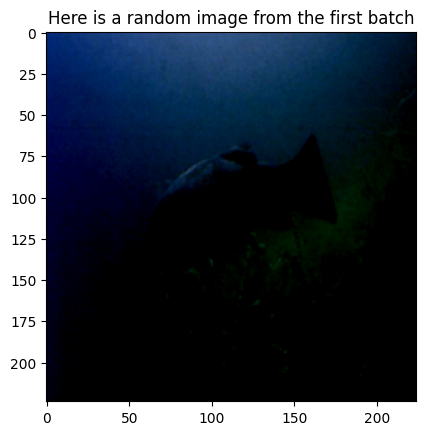

Label: 0


In [14]:
"""Visualizing a random image from the imagenette dataset"""
rand_idx = torch.randint(0, BATCH_SIZE, (1,)).item() # Generates random numbers from 0 to BATCH_SIZE-1; the (1,) parameter basically indicates pytorch to return a tensor with a single element
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
print(train_features[0].shape)
print(train_features[0].squeeze().shape)
img = train_features[0].squeeze() # [B, H, W] -> [H, W]
img = img.permute(1, 2, 0) # [3, 224, 224] -> [224, 224, 3] | Matplotlib accepts just the Channels-Last format
label = train_labels[0]

plt.imshow(img, cmap='gray')
plt.title("Here is a random image from the first batch")
plt.show()
print(f"Label: {label}")

# Training loop breakdown
- Iterations per epoch: **9.469/64 (batch size) = ~148 steps**
- Total iterations: **74 x 40 (epochs) = 2.960**

In [49]:
crit = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, weight_decay=0.0005, lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
)

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [65]:
train_loss = []

for epoch in range(40):
  model.train()
  running_loss = 0.
  epoch_loss = 0.
  for batch_idx, (inputs, labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = crit(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    epoch_loss += loss.item()
    if (batch_idx + 1) % 100 == 0:
      print(f" epoch {epoch+1} | batch {batch_idx+1} | loss: {running_loss/100:.3f}")
      running_loss = 0.
  avg_epoch_loss = epoch_loss / len(train_loader)
  train_loss.append(avg_epoch_loss)
  print(f"Final epoch {epoch+1} | Mean Loss: {avg_epoch_loss:.3f}")
  scheduler.step(avg_epoch_loss)

 epoch 1 | batch 100 | loss: 2.355
Final epoch 1 | Mean Loss: 2.351
 epoch 2 | batch 100 | loss: 2.340
Final epoch 2 | Mean Loss: 2.341
 epoch 3 | batch 100 | loss: 2.332
Final epoch 3 | Mean Loss: 2.333
 epoch 4 | batch 100 | loss: 2.329
Final epoch 4 | Mean Loss: 2.331
 epoch 5 | batch 100 | loss: 2.333
Final epoch 5 | Mean Loss: 2.332
 epoch 6 | batch 100 | loss: 2.326
Final epoch 6 | Mean Loss: 2.326
 epoch 7 | batch 100 | loss: 2.325
Final epoch 7 | Mean Loss: 2.325
 epoch 8 | batch 100 | loss: 2.329
Final epoch 8 | Mean Loss: 2.329
 epoch 9 | batch 100 | loss: 2.327
Final epoch 9 | Mean Loss: 2.326
 epoch 10 | batch 100 | loss: 2.325
Final epoch 10 | Mean Loss: 2.326
 epoch 11 | batch 100 | loss: 2.322
Final epoch 11 | Mean Loss: 2.322
 epoch 12 | batch 100 | loss: 2.322
Final epoch 12 | Mean Loss: 2.322
 epoch 13 | batch 100 | loss: 2.319
Final epoch 13 | Mean Loss: 2.321
 epoch 14 | batch 100 | loss: 2.326
Final epoch 14 | Mean Loss: 2.324
 epoch 15 | batch 100 | loss: 2.318
Fi

In [71]:
val_loss = []
y_true = []
y_pred = []
total = 0
correct = 0
running_val_loss = 0.0
model.eval()
with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    loss = crit(outputs, labels)
    predicted = torch.argmax(outputs, dim=1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    val_loss.append(loss.item())
    running_val_loss += loss.item()
    y_true.extend(labels.cpu().tolist())
    y_pred.extend(predicted.cpu().tolist())
  accuracy = 100 * correct / total
  avg_val_loss = running_val_loss / len(val_loader)

In [72]:
print(f"The average val loss is: {avg_val_loss:.2f}")

The average val loss is: 0.81


## Let's now visualize the loss on both train and validation splits of **Imagenette** ##

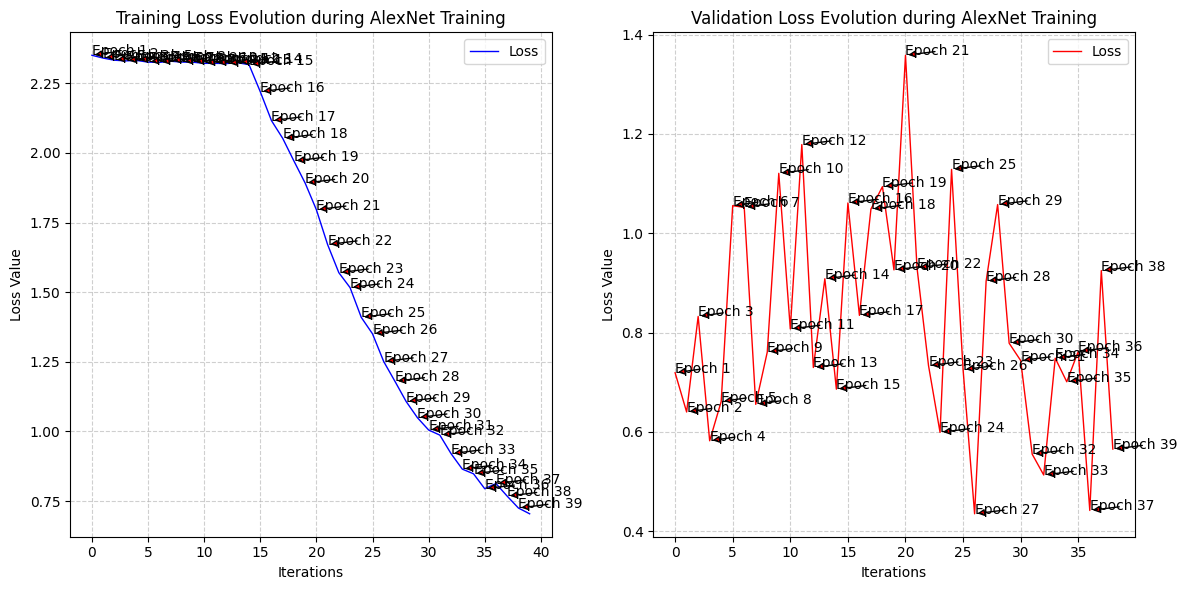

In [83]:
"""Mostly boilerplate/boring matplotlib code"""

# Downsample by averaging every N batches
step = len(val_loss) // 39
epoch_val_loss = [sum(val_loss[i:i+step])/step for i in range(0, len(val_loss), step)][:39]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

"""Plot training loss"""
ax1.plot(train_loss, label='Loss', color='blue', linewidth=1)

ax1.set_title("Training Loss Evolution during AlexNet Training")
ax1.set_xlabel("Iterations")
ax1.set_ylabel('Loss Value')
ax1.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 40): # 40 is the number of epochs we trained the "AlexNet-from-scratch in Pytorch" model for
    ax1.annotate(f'Epoch {i}', xy=(i-1, train_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax1.legend()

"""Plot validation loss"""
ax2.plot(epoch_val_loss, label='Loss', color='red', linewidth=1)
ax2.set_title("Validation Loss Evolution during AlexNet Training")
ax2.set_xlabel("Iterations")
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.6)
for i in range(1, 40):
    ax2.annotate(f'Epoch {i}', xy=(i-1, epoch_val_loss[i-1]), arrowprops=dict(facecolor='red', arrowstyle='-|>', edgecolor='black'))
ax2.legend()

plt.tight_layout()
plt.show()


# The Confusion Matrix

In [74]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [75]:
confusion_mat = confusion_matrix(y_true, y_pred)

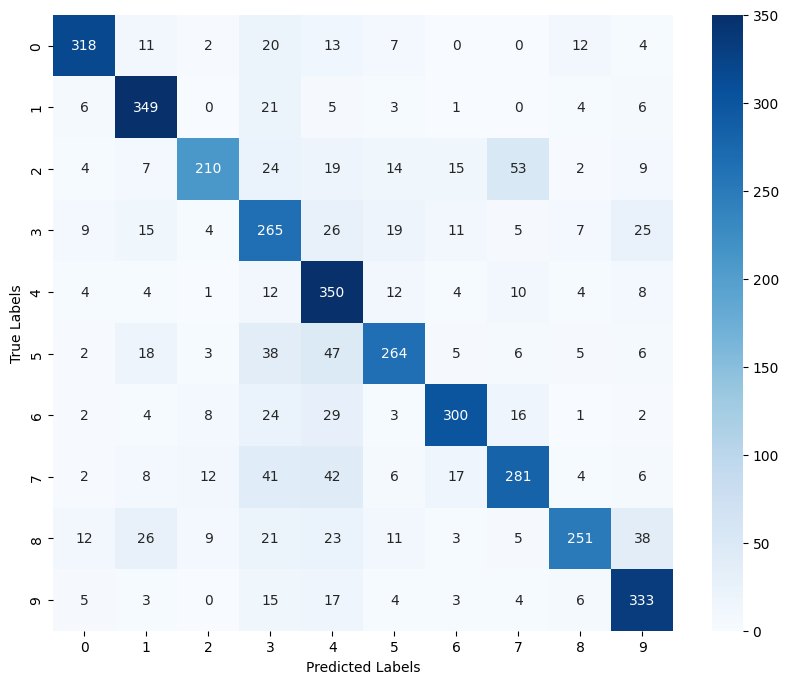

In [76]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report

In [77]:
from sklearn.metrics import classification_report
import pandas as pd

In [78]:
cls_rep = classification_report(y_true, y_pred)

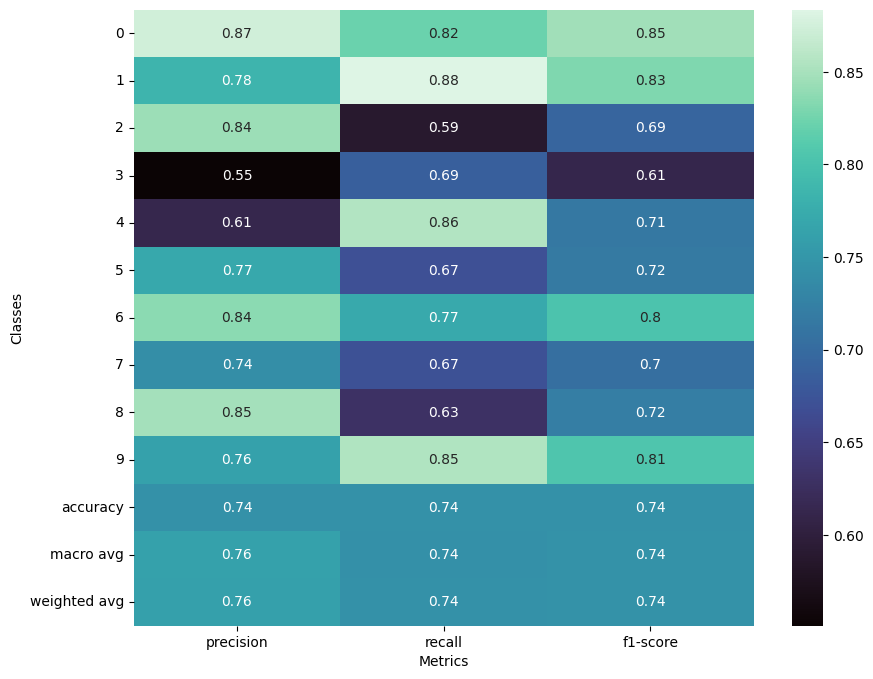

In [79]:
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).iloc[:-1, :].T, cmap='mako', annot=True)
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.show()

### **Torchvision-imported AlexNet Model Performance Analysis**
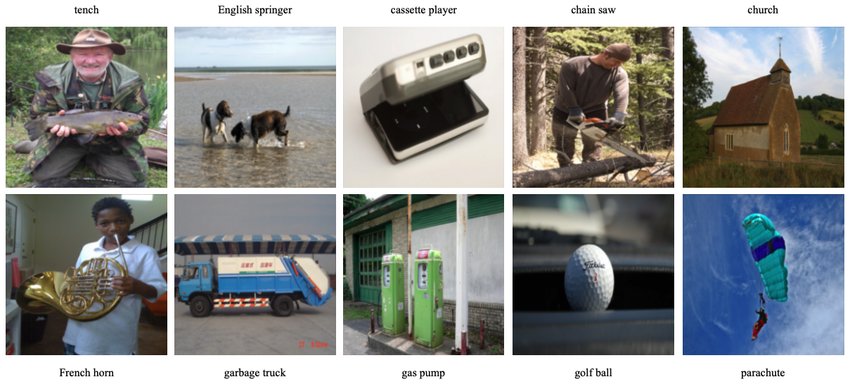

It seems that the default torchvision AlexNet suffered clear overfitting on this dataset
